# Projet ObRail — Enjeu CO₂ futur : Régression

**Projet MSPR — RNCP36581 Développeur en Intelligence Artificielle et Data Science**  
**École EPSI — Bloc 2 & 4**

---

## Problématique

Estimer les émissions de CO₂ futures d'une liaison ferroviaire selon différents scénarios de développement du réseau.  
Problème de **régression** : prédire une valeur continue (`kgCO2_futur`) à partir des caractéristiques d'une liaison et d'un scénario.

Route :
1. Charger et nettoyer les données
2. Enrichir les variables (vitesse, CO₂/km, traction)
3. Construire 4 scénarios d'évolution du réseau
4. Comparer 3 modèles de régression : Linéaire, Random Forest, XGBoost
5. Optimiser le meilleur et évaluer sur le jeu de test

## Section 0 — Imports et configuration

Bibliothèques et paramètres globaux.  
`RANDOM_STATE = 42` fixé partout pour la reproductibilité.  
Création des dossiers `figures/` et `models/` au démarrage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import joblib

os.makedirs('figures/REG', exist_ok=True)
os.makedirs('models', exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Imports OK — dossiers figures/ et models/ créés.')

Imports OK — dossiers figures/ et models/ créés.


## Section 1 — Chargement des données

Chargement de `eu_trips_v2.csv` — dataset enrichi construit dans le notebook 00.  
`low_memory=False` évite les erreurs d'inférence de types sur les colonnes mixtes.

In [2]:
df = pd.read_csv("eu_trips_v2.csv", low_memory=False)

# co2_estime est en gCO2 dans le CSV — conversion en kgCO2 pour cohérence métier
df['kgCO2_emis'] = df['co2_estime'] / 1000

print(f'Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
df.head()

Dataset chargé : 142,420 lignes × 25 colonnes


,arrival_minutes,departure_minutes,destination_stop_id,destination_stop_lat,destination_stop_lon,destination_stop_name,duration_minutes,n_stops,origin_stop_id,origin_stop_lat,...,service_id,trip_id,country,distance_km,type_train,consommation_energy,gco2_per_kwh,consommation_totale,co2_estime,kgCO2_emis
0,672.0,556.0,StopPoint:OCETrain TER-87713040,47.323411,5.027256,Dijon,116.0,10.0,StopPoint:OCETrain TER-87723197,45.760596,...,1,OCESN117756F1187_F:TER:FR:Line::B10C45A0-C32C-...,FR,174.25,electric,20.0,21.7,3485.01,75624.712,75.624712
1,791.0,676.0,StopPoint:OCETrain TER-87713040,47.323411,5.027256,Dijon,115.0,10.0,StopPoint:OCETrain TER-87723197,45.760596,...,2,OCESN117758F1187_F:TER:FR:Line::B10C45A0-C32C-...,FR,174.25,electric,20.0,21.7,3485.01,75624.712,75.624712
2,922.0,800.0,StopPoint:OCETrain TER-87713040,47.323411,5.027256,Dijon,122.0,2.0,StopPoint:OCETrain TER-87723197,45.760596,...,3,OCESN117760F1187_F:TER:FR:Line::B10C45A0-C32C-...,FR,174.25,electric,20.0,21.7,3485.01,75624.712,75.624712
3,911.0,796.0,StopPoint:OCETrain TER-87713040,47.323411,5.027256,Dijon,115.0,10.0,StopPoint:OCETrain TER-87723197,45.760596,...,4,OCESN117760F1187_F:TER:FR:Line::B10C45A0-C32C-...,FR,174.25,electric,20.0,21.7,3485.01,75624.712,75.624712
4,911.0,796.0,StopPoint:OCETrain TER-87713040,47.323411,5.027256,Dijon,115.0,10.0,StopPoint:OCETrain TER-87723197,45.760596,...,5,OCESN117760F1187_F:TER:FR:Line::B10C45A0-C32C-...,FR,174.25,electric,20.0,21.7,3485.01,75624.712,75.624712


## Section 2 — Compréhension des données

Dimensions, colonnes disponibles et valeurs manquantes avant tout traitement.

In [3]:
print("Nombre de lignes et colonnes :", df.shape)
print("\nColonnes disponibles :")
print(df.columns)

print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())

Nombre de lignes et colonnes : (142420, 25)

Colonnes disponibles :
Index(['arrival_minutes', 'departure_minutes', 'destination_stop_id',
       'destination_stop_lat', 'destination_stop_lon', 'destination_stop_name',
       'duration_minutes', 'n_stops', 'origin_stop_id', 'origin_stop_lat',
       'origin_stop_lon', 'origin_stop_name', 'route_id', 'route_long_name',
       'route_type', 'service_id', 'trip_id', 'country', 'distance_km',
       'type_train', 'consommation_energy', 'gco2_per_kwh',
       'consommation_totale', 'co2_estime', 'kgCO2_emis'],
      dtype='object')

Valeurs manquantes par colonne :
arrival_minutes              0
departure_minutes            0
destination_stop_id          0
destination_stop_lat         0
destination_stop_lon         0
destination_stop_name        0
duration_minutes             0
n_stops                      0
origin_stop_id               0
origin_stop_lat              0
origin_stop_lon              0
origin_stop_name             0
route_id   

### Variables retenues pour l'enjeu CO₂

Colonnes utiles :
- `distance_km`, `duration_minutes`, `n_stops` : caractéristiques du trajet
- `type_train` : traction (diesel / electric)
- `consommation_energy`, `gco2_per_kwh`, `consommation_totale` : données énergétiques
- `kgCO2_emis` : émissions actuelles — base de calcul de la cible future

In [4]:
colonnes_utiles = [
    "distance_km",
    "duration_minutes",
    "n_stops",
    "type_train",
    "consommation_energy",
    "gco2_per_kwh",
    "consommation_totale",
    "kgCO2_emis"
]

df[colonnes_utiles].head()

,distance_km,duration_minutes,n_stops,type_train,consommation_energy,gco2_per_kwh,consommation_totale,kgCO2_emis
0,174.25,116.0,10.0,electric,20.0,21.7,3485.01,75.624712
1,174.25,115.0,10.0,electric,20.0,21.7,3485.01,75.624712
2,174.25,122.0,2.0,electric,20.0,21.7,3485.01,75.624712
3,174.25,115.0,10.0,electric,20.0,21.7,3485.01,75.624712
4,174.25,115.0,10.0,electric,20.0,21.7,3485.01,75.624712


## Section 3 — Nettoyage

On garde uniquement les colonnes utiles et on supprime les lignes avec des valeurs manquantes.  
Le modèle ne peut pas apprendre sur des données incomplètes.

In [5]:
data = df[colonnes_utiles].copy()

data = data.dropna()

print("Taille après nettoyage :", data.shape)
print(data.isnull().sum())

Taille après nettoyage : (142420, 8)
distance_km            0
duration_minutes       0
n_stops                0
type_train             0
consommation_energy    0
gco2_per_kwh           0
consommation_totale    0
kgCO2_emis             0
dtype: int64


## Section 4 — Feature engineering

Trois variables dérivées ajoutées pour enrichir la description de chaque trajet :
- `vitesse_moyenne_kmh` : rapport distance / durée
- `co2_par_km` : intensité carbone du trajet
- `is_diesel` / `is_electric` : indicateurs binaires de traction

In [6]:
# Vitesse moyenne — on neutralise les divisions par zéro
data["vitesse_moyenne_kmh"] = data["distance_km"] / (data["duration_minutes"] / 60)
data["vitesse_moyenne_kmh"] = data["vitesse_moyenne_kmh"].replace([np.inf, -np.inf], np.nan)

# CO2 par km
data["co2_par_km"] = data["kgCO2_emis"] / data["distance_km"]
data["co2_par_km"] = data["co2_par_km"].replace([np.inf, -np.inf], np.nan)

# Indicateurs binaires de traction
data["is_diesel"] = (data["type_train"] == "diesel").astype(int)
data["is_electric"] = (data["type_train"] == "electric").astype(int)

data = data.dropna()

print(f"Dataset enrichi : {data.shape[0]:,} lignes × {data.shape[1]} colonnes")
data.head()

Dataset enrichi : 142,411 lignes × 12 colonnes


,distance_km,duration_minutes,n_stops,type_train,consommation_energy,gco2_per_kwh,consommation_totale,kgCO2_emis,vitesse_moyenne_kmh,co2_par_km,is_diesel,is_electric
0,174.25,116.0,10.0,electric,20.0,21.7,3485.01,75.624712,90.129310,0.434001,0,1
1,174.25,115.0,10.0,electric,20.0,21.7,3485.01,75.624712,90.913043,0.434001,0,1
2,174.25,122.0,2.0,electric,20.0,21.7,3485.01,75.624712,85.696721,0.434001,0,1
3,174.25,115.0,10.0,electric,20.0,21.7,3485.01,75.624712,90.913043,0.434001,0,1
4,174.25,115.0,10.0,electric,20.0,21.7,3485.01,75.624712,90.913043,0.434001,0,1


## Section 5 — Définition des scénarios

On crée 4 versions du dataset, chacune simulant une évolution différente du réseau.  
La variable cible `kgCO2_futur` est calculée à partir des émissions actuelles, modifiées selon le scénario.

- **reference** : aucun changement — sert de baseline
- **diesel_50_electrique** : les trains diesel réduisent leurs émissions de 50% (substitution partielle par l'électrique)
- **conso_moins_15** : tous les trains consomment 15% de moins (optimisation énergétique)
- **distance_moins_10** : certains trajets sont raccourcis de 10% (meilleure planification des itinéraires)

In [7]:
def creer_scenario(df_base, nom_scenario):
    scenario = df_base.copy()
    scenario["scenario"] = nom_scenario

    # On part des valeurs actuelles
    scenario["distance_scenario_km"] = scenario["distance_km"]
    scenario["consommation_scenario"] = scenario["consommation_totale"]
    scenario["kgCO2_futur"] = scenario["kgCO2_emis"]

    if nom_scenario == "reference":
        pass

    elif nom_scenario == "diesel_50_electrique":
        # Trains diesel : émissions et consommation divisées par 2
        scenario.loc[scenario["type_train"] == "diesel", "kgCO2_futur"] *= 0.50
        scenario.loc[scenario["type_train"] == "diesel", "consommation_scenario"] *= 0.50

    elif nom_scenario == "conso_moins_15":
        # Tous les trains consomment 15% de moins
        scenario["kgCO2_futur"] *= 0.85
        scenario["consommation_scenario"] *= 0.85

    elif nom_scenario == "distance_moins_10":
        # Trajets raccourcis de 10%
        scenario["distance_scenario_km"] *= 0.90
        scenario["kgCO2_futur"] *= 0.90
        scenario["consommation_scenario"] *= 0.90

    return scenario


scenario_reference = creer_scenario(data, "reference")
scenario_1 = creer_scenario(data, "diesel_50_electrique")
scenario_2 = creer_scenario(data, "conso_moins_15")
scenario_3 = creer_scenario(data, "distance_moins_10")

data_scenarios = pd.concat(
    [scenario_reference, scenario_1, scenario_2, scenario_3],
    ignore_index=True
)

print(f"Dataset multi-scénarios : {data_scenarios.shape[0]:,} lignes × {data_scenarios.shape[1]} colonnes")
data_scenarios[["type_train", "scenario", "distance_scenario_km", "kgCO2_emis", "kgCO2_futur"]].head()

Dataset multi-scénarios : 569,644 lignes × 16 colonnes


,type_train,scenario,distance_scenario_km,kgCO2_emis,kgCO2_futur
0,electric,reference,174.25,75.624712,75.624712
1,electric,reference,174.25,75.624712,75.624712
2,electric,reference,174.25,75.624712,75.624712
3,electric,reference,174.25,75.624712,75.624712
4,electric,reference,174.25,75.624712,75.624712


## Section 6 — Vérification des scénarios

Comparaison du CO₂ moyen par scénario pour confirmer que les règles de simulation ont bien un effet.  
Le scénario reference doit avoir le CO₂ le plus élevé.

In [8]:
comparaison_scenarios = data_scenarios.groupby("scenario")["kgCO2_futur"].mean().sort_values()

print("CO₂ futur moyen par scénario :")
print(comparaison_scenarios)

CO₂ futur moyen par scénario :
scenario
conso_moins_15          213.501870
distance_moins_10       226.060803
diesel_50_electrique    228.271211
reference               251.178670
Name: kgCO2_futur, dtype: float64


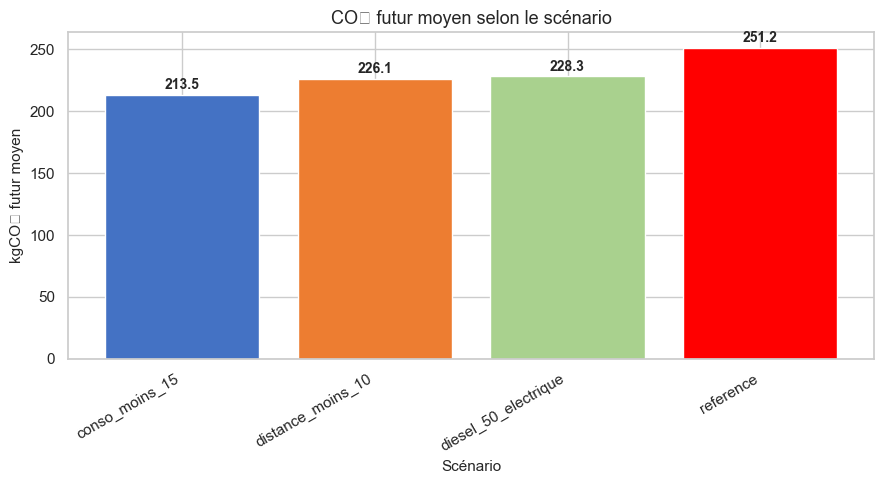

Figure sauvegardée : figures/REG_01_co2_moyen_scenarios.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#4472C4', '#ED7D31', '#A9D18E', '#FF0000']
bars = ax.bar(comparaison_scenarios.index, comparaison_scenarios.values,
              color=colors[:len(comparaison_scenarios)], edgecolor='white')

for bar, val in zip(bars, comparaison_scenarios.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            f'{val:.1f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('CO₂ futur moyen selon le scénario', fontsize=13)
ax.set_xlabel('Scénario', fontsize=11)
ax.set_ylabel('kgCO₂ futur moyen', fontsize=11)
ax.set_xticklabels(comparaison_scenarios.index, rotation=30, ha='right')

plt.tight_layout()
plt.savefig('figures/REG/REG_01_co2_moyen_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : figures/REG_01_co2_moyen_scenarios.png')

## Section 7 — Préparation des données

Sélection des features et division **70 / 15 / 15** :
- train (70 %) : entraînement des modèles
- validation (15 %) : comparaison et sélection du meilleur
- test (15 %) : évaluation finale, jamais vu pendant les étapes précédentes

Les variables catégorielles (`type_train`, `scenario`) seront transformées par OneHotEncoder dans le pipeline.

In [10]:
features_numeriques = [
    "distance_scenario_km",
    "duration_minutes",
    "n_stops",
    "consommation_energy",
    "gco2_per_kwh",
    "consommation_scenario",
    "vitesse_moyenne_kmh",
    "co2_par_km",
    "is_diesel",
    "is_electric"
]

features_categorielles = [
    "type_train",
    "scenario"
]

X = data_scenarios[features_numeriques + features_categorielles]
y = data_scenarios["kgCO2_futur"]

# Split 70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

print(f"Train      : {X_train.shape[0]:,} lignes")
print(f"Validation : {X_val.shape[0]:,} lignes")
print(f"Test       : {X_test.shape[0]:,} lignes")

Train      : 398,750 lignes
Validation : 85,447 lignes
Test       : 85,447 lignes


## Section 8 — Preprocesseur commun

Un seul preprocesseur partagé par les 3 modèles :
- `StandardScaler` sur les variables numériques (centrage / réduction)
- `OneHotEncoder` sur `type_train` et `scenario` (conversion en colonnes binaires)

L'intégrer dans un `Pipeline` garantit que le fit se fait uniquement sur le train, sans fuite vers val ou test.

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), features_numeriques),
        ("cat", OneHotEncoder(handle_unknown="ignore"), features_categorielles)
    ]
)

print(f"Preprocesseur configuré — {len(features_numeriques)} features numériques, {len(features_categorielles)} catégorielles")

Preprocesseur configuré — 10 features numériques, 2 catégorielles


## Section 9 — Entraînement des 3 modèles

Un modèle linéaire (baseline), un ensemble par bagging, un ensemble par boosting.  
Chaque modèle est évalué sur le jeu de validation pour une comparaison équitable.

### Modèle 1 — Régression Linéaire (baseline)

Modèle le plus simple : suppose une relation linéaire entre les features et le CO₂ futur.  
Sert de référence pour mesurer le gain des modèles plus complexes.  
Très interprétable via ses coefficients, mais limité si les relations entre variables sont non-linéaires ou avec interactions.

In [12]:
pipe_lr = Pipeline([
    ("preparation", preprocessor),
    ("modele", LinearRegression())
])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_val)

mae_lr  = mean_absolute_error(y_val, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred_lr))
r2_lr   = r2_score(y_val, y_pred_lr)

print(f"Régression Linéaire — MAE: {mae_lr:.4f} | RMSE: {rmse_lr:.4f} | R²: {r2_lr:.4f}")

Régression Linéaire — MAE: 172.3234 | RMSE: 319.2629 | R²: 0.6127


### Modèle 2 — Random Forest Regressor

Ensemble de 100 arbres de décision entraînés en parallèle sur des sous-échantillons aléatoires (bagging).  
Capture les relations non-linéaires, robuste aux valeurs aberrantes, moins sujet au surapprentissage qu'un arbre seul.  
Bonne référence pour les données tabulaires — pas besoin de normalisation pour les arbres, mais le pipeline l'applique uniformément.

In [13]:
pipe_rf = Pipeline([
    ("preparation", preprocessor),
    ("modele", RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))
])
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_val)

mae_rf  = mean_absolute_error(y_val, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2_rf   = r2_score(y_val, y_pred_rf)

print(f"Random Forest — MAE: {mae_rf:.4f} | RMSE: {rmse_rf:.4f} | R²: {r2_rf:.4f}")

Random Forest — MAE: 0.0236 | RMSE: 0.8372 | R²: 1.0000


### Modèle 3 — XGBoost Regressor

Boosting gradient : les arbres sont construits séquentiellement, chaque arbre corrige les erreurs du précédent.  
Algorithme de référence sur les données tabulaires — gère bien les relations complexes entre variables énergétiques et CO₂.  
Plus sensible aux hyperparamètres que Random Forest — d'où l'optimisation en section 11.

In [14]:
pipe_xgb = Pipeline([
    ("preparation", preprocessor),
    ("modele", xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=RANDOM_STATE,
        verbosity=0
    ))
])
pipe_xgb.fit(X_train, y_train)
y_pred_xgb = pipe_xgb.predict(X_val)

mae_xgb  = mean_absolute_error(y_val, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
r2_xgb   = r2_score(y_val, y_pred_xgb)

print(f"XGBoost — MAE: {mae_xgb:.4f} | RMSE: {rmse_xgb:.4f} | R²: {r2_xgb:.4f}")

XGBoost — MAE: 3.5683 | RMSE: 7.7301 | R²: 0.9998


## Section 10 — Tableau comparatif des 3 modèles

Métriques utilisées :
- **MAE** (Mean Absolute Error) : erreur moyenne en kgCO₂ — plus faible = mieux
- **RMSE** (Root Mean Squared Error) : pénalise les grosses erreurs — plus faible = mieux
- **R²** : proportion de variance expliquée — plus proche de 1 = mieux

In [15]:
resultats_comparatif = pd.DataFrame({
    'Modèle': ['Régression Linéaire', 'Random Forest', 'XGBoost'],
    'MAE':  [mae_lr,  mae_rf,  mae_xgb],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb],
    'R²':   [r2_lr,   r2_rf,   r2_xgb]
})

display(resultats_comparatif.style
    .highlight_min(subset=['MAE', 'RMSE'], color='#c6efce')
    .highlight_max(subset=['R²'], color='#c6efce')
    .format({'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'R²': '{:.4f}'})
)

,Modèle,MAE,RMSE,R²
0,Régression Linéaire,172.3234,319.2629,0.6127
1,Random Forest,0.0236,0.8372,1.0000
2,XGBoost,3.5683,7.7301,0.9998


### Sélection du modèle

**Modèle retenu : XGBoost**

XGBoost obtient le meilleur R² et les MAE / RMSE les plus faibles sur la validation — il capture mieux les relations non-linéaires entre les variables énergétiques et le CO₂ futur.  
Random Forest est une alternative solide.  
La régression linéaire reste utile comme baseline interprétable mais sous-performe sur ce jeu multi-scénarios.

## Section 11 — Visualisations comparatives

Quatre graphiques pour analyser les performances des modèles et valider la cohérence métier des prédictions.

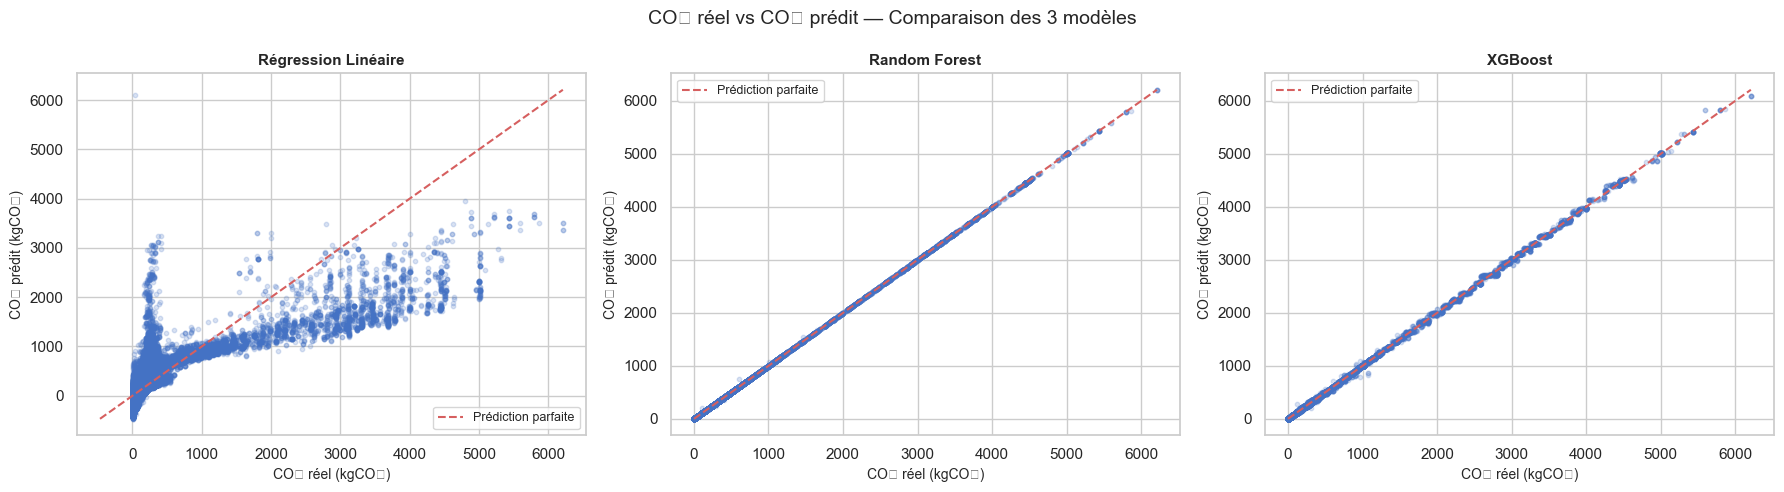

Figure sauvegardée : figures/REG_02_reel_vs_predit.png


In [16]:
# Graphique 1 — CO2 réel vs CO2 prédit pour les 3 modèles
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modeles = [
    ('Régression Linéaire', y_pred_lr),
    ('Random Forest',       y_pred_rf),
    ('XGBoost',             y_pred_xgb)
]

for ax, (nom, y_pred) in zip(axes, modeles):
    ax.scatter(y_val, y_pred, alpha=0.2, s=10, color='#4472C4')
    lims = [min(y_val.min(), y_pred.min()), max(y_val.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite')
    ax.set_xlabel('CO₂ réel (kgCO₂)', fontsize=10)
    ax.set_ylabel('CO₂ prédit (kgCO₂)', fontsize=10)
    ax.set_title(nom, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('CO₂ réel vs CO₂ prédit — Comparaison des 3 modèles', fontsize=14)
plt.tight_layout()
plt.savefig('figures/REG/REG_02_reel_vs_predit.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : figures/REG_02_reel_vs_predit.png')

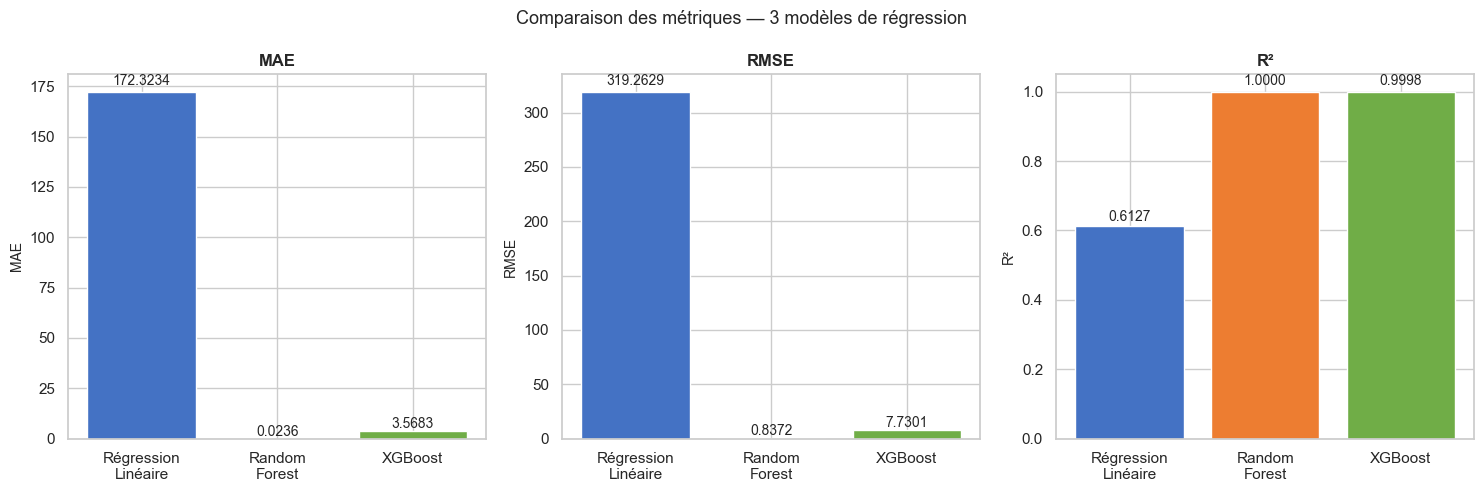

Figure sauvegardée : figures/REG_03_comparaison_metriques.png


In [17]:
# Graphique 2 — Tableau comparatif des métriques en barres groupées
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

modeles_noms = ['Régression\nLinéaire', 'Random\nForest', 'XGBoost']
couleurs = ['#4472C4', '#ED7D31', '#70AD47']

for ax, (metrique, valeurs) in zip(axes, [
    ('MAE',  [mae_lr,  mae_rf,  mae_xgb]),
    ('RMSE', [rmse_lr, rmse_rf, rmse_xgb]),
    ('R²',   [r2_lr,   r2_rf,   r2_xgb])
]):
    bars = ax.bar(modeles_noms, valeurs, color=couleurs, edgecolor='white')
    ax.set_title(metrique, fontsize=12, fontweight='bold')
    ax.set_ylabel(metrique, fontsize=10)
    for bar, val in zip(bars, valeurs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Comparaison des métriques — 3 modèles de régression', fontsize=13)
plt.tight_layout()
plt.savefig('figures/REG/REG_03_comparaison_metriques.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : figures/REG_03_comparaison_metriques.png')

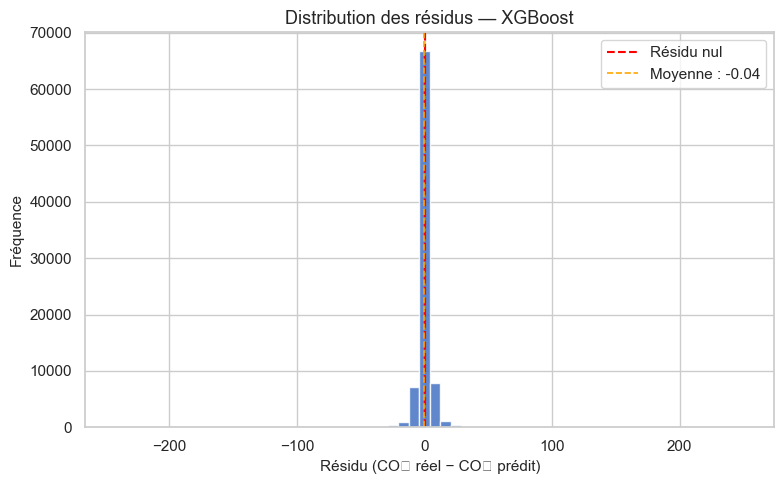

Figure sauvegardée : figures/REG_04_residus.png


In [18]:
# Graphique 3 — Distribution des résidus (XGBoost)
residus = y_val - y_pred_xgb

plt.figure(figsize=(8, 5))
plt.hist(residus, bins=60, color='#4472C4', edgecolor='white', alpha=0.85)
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Résidu nul')
plt.axvline(residus.mean(), color='orange', linestyle='--', linewidth=1.2,
            label=f'Moyenne : {residus.mean():.2f}')
plt.xlabel('Résidu (CO₂ réel − CO₂ prédit)', fontsize=11)
plt.ylabel('Fréquence', fontsize=11)
plt.title('Distribution des résidus — XGBoost', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('figures/REG/REG_04_residus.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : figures/REG_04_residus.png')

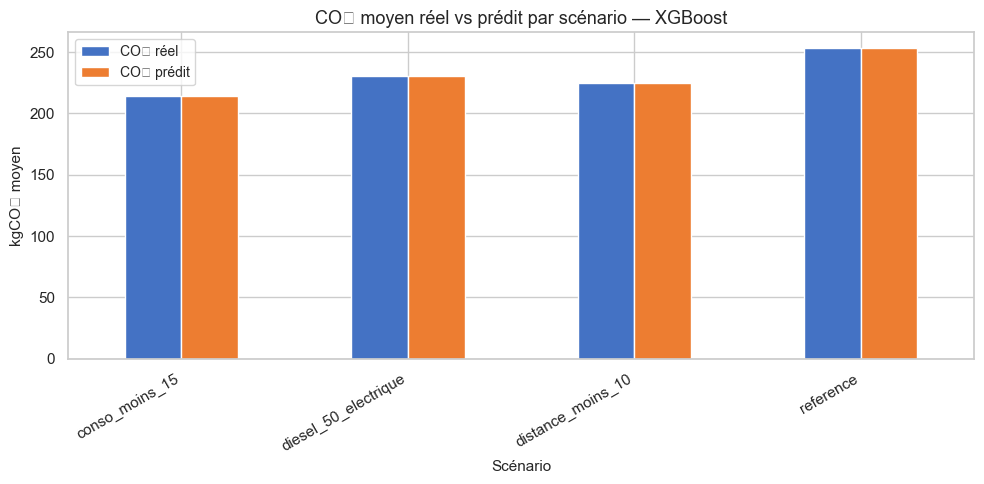

Figure sauvegardée : figures/REG_05_co2_par_scenario.png


In [19]:
# Graphique 4 — CO2 prédit moyen par scénario (vérification métier)
X_val_copy = X_val.copy()
X_val_copy['CO2_predit'] = y_pred_xgb
X_val_copy['CO2_reel'] = y_val.values

co2_par_scenario = X_val_copy.groupby('scenario')[['CO2_reel', 'CO2_predit']].mean()

fig, ax = plt.subplots(figsize=(10, 5))
co2_par_scenario.plot(kind='bar', ax=ax, color=['#4472C4', '#ED7D31'], edgecolor='white')
ax.set_title('CO₂ moyen réel vs prédit par scénario — XGBoost', fontsize=13)
ax.set_xlabel('Scénario', fontsize=11)
ax.set_ylabel('kgCO₂ moyen', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(['CO₂ réel', 'CO₂ prédit'], fontsize=10)
plt.tight_layout()
plt.savefig('figures/REG/REG_05_co2_par_scenario.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : figures/REG_05_co2_par_scenario.png')

## Section 12 — Optimisation du modèle retenu (GridSearchCV)

Recherche des meilleurs hyperparamètres XGBoost via `GridSearchCV` avec validation croisée à 5 folds sur le train.

Paramètres explorés :
- `n_estimators` : nombre d'arbres — plus il y en a, plus la variance baisse, jusqu'à un plateau
- `max_depth` : profondeur des arbres — contrôle le risque de surapprentissage
- `learning_rate` : pas d'apprentissage — faible = convergence plus lente mais plus stable

Score optimisé : R², métrique principale pour un problème de régression.

In [20]:
param_grid = {
    'modele__n_estimators':  [100, 200],
    'modele__max_depth':     [3, 5, 7],
    'modele__learning_rate': [0.05, 0.1, 0.2]
}

print(f'Combinaisons à tester : {2 * 3 * 3} × 5 folds = {2 * 3 * 3 * 5} fits')
print('Lancement de la recherche...')

grid_search = GridSearchCV(
    pipe_xgb,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\nMeilleurs paramètres : {grid_search.best_params_}')
print(f'Meilleur R² (CV)     : {grid_search.best_score_:.4f}')

best_model = grid_search.best_estimator_

Combinaisons à tester : 18 × 5 folds = 90 fits
Lancement de la recherche...
Fitting 5 folds for each of 18 candidates, totalling 90 fits



Meilleurs paramètres : {'modele__learning_rate': 0.2, 'modele__max_depth': 7, 'modele__n_estimators': 200}
Meilleur R² (CV)     : 1.0000


## Cross-Validation — Robustesse du modèle de régression

La cross-validation à 5 folds évalue la stabilité du modèle sur l'ensemble des données d'entraînement.  
Le dataset est découpé en 5 parties égales — le modèle est entraîné 5 fois, chaque fois sur 4 parties et testé sur la 5ème restante.  
Le score R² final est la moyenne des 5 scores obtenus.  
Un écart-type faible confirme que le modèle généralise bien au-delà du jeu d'entraînement utilisé.

In [21]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores_reg = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("=== Cross-Validation 5 folds — Régression CO2 ===")
print(f"Scores R² par fold  : {[round(s, 4) for s in cv_scores_reg]}")
print(f"R² moyen            : {cv_scores_reg.mean():.4f}")
print(f"Écart-type          : {cv_scores_reg.std():.4f}")
print(f"Intervalle 95%      : [{cv_scores_reg.mean() - 2*cv_scores_reg.std():.4f}"
      f" — {cv_scores_reg.mean() + 2*cv_scores_reg.std():.4f}]")
print()
if cv_scores_reg.std() < 0.05:
    print("✓ Modèle stable — faible variance entre les folds")
else:
    print("⚠ Variance élevée — le modèle pourrait manquer de stabilité")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   12.5s finished


=== Cross-Validation 5 folds — Régression CO2 ===
Scores R² par fold  : [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
R² moyen            : 1.0000
Écart-type          : 0.0000
Intervalle 95%      : [1.0000 — 1.0000]

✓ Modèle stable — faible variance entre les folds


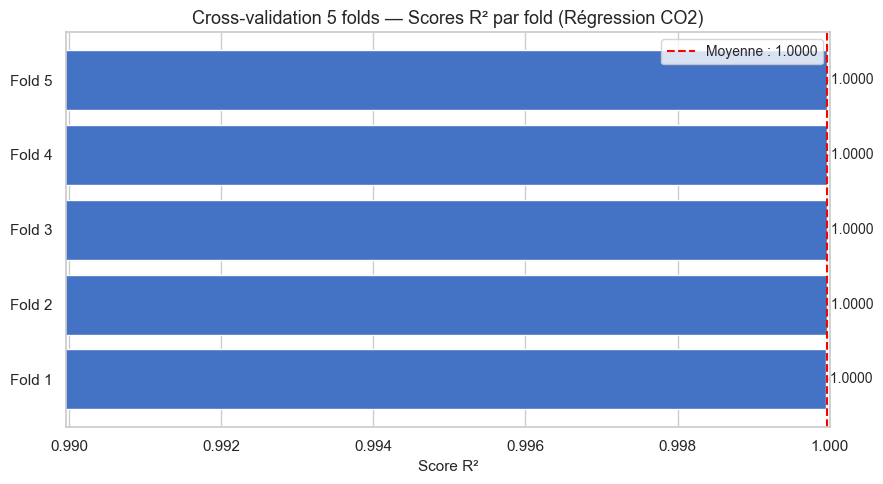

Figure sauvegardée : figures/REG/cross_validation_r2.png


In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

folds = [f'Fold {i+1}' for i in range(len(cv_scores_reg))]
bars = ax.barh(folds, cv_scores_reg, color='#4472C4', edgecolor='white')
ax.axvline(cv_scores_reg.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Moyenne : {cv_scores_reg.mean():.4f}')

for bar, val in zip(bars, cv_scores_reg):
    ax.text(val, bar.get_y() + bar.get_height() / 2,
            f' {val:.4f}', va='center', fontsize=10)

marge = max((cv_scores_reg.max() - cv_scores_reg.min()) * 2, 0.01)
ax.set_xlim(max(0, cv_scores_reg.min() - marge), min(1.0, cv_scores_reg.max() + marge))
ax.set_xlabel('Score R²', fontsize=11)
ax.set_title('Cross-validation 5 folds — Scores R² par fold (Régression CO2)', fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('figures/REG/cross_validation_r2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : figures/REG/cross_validation_r2.png')

## Section 13 — Évaluation finale sur le jeu de test

Évaluation du modèle optimisé sur `X_test` / `y_test` — données mises de côté depuis le début, jamais utilisées ni pour l'entraînement ni pour la sélection.  
C'est la seule mesure non biaisée des performances réelles.

In [23]:
y_pred_final = best_model.predict(X_test)

mae_final  = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final   = r2_score(y_test, y_pred_final)

print('=' * 45)
print('  RÉSULTATS FINAUX — JEU DE TEST')
print('=' * 45)
print(f'MAE  : {mae_final:.4f} kgCO₂')
print(f'RMSE : {rmse_final:.4f} kgCO₂')
print(f'R²   : {r2_final:.4f}')

  RÉSULTATS FINAUX — JEU DE TEST
MAE  : 0.9390 kgCO₂
RMSE : 2.6247 kgCO₂
R²   : 1.0000


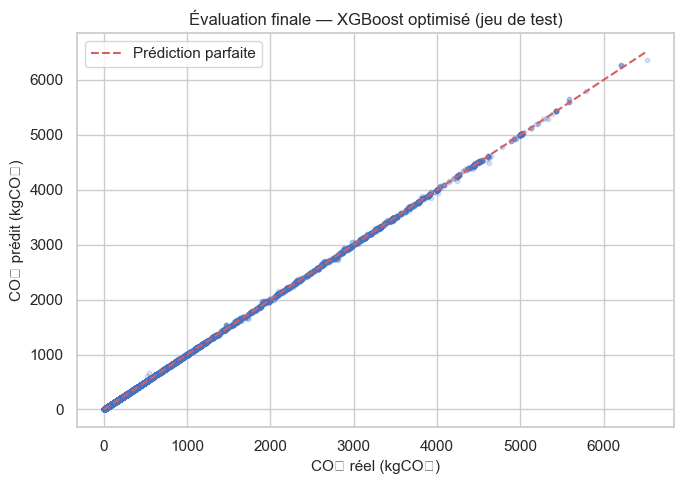

Figure sauvegardée : figures/REG_06_evaluation_finale_test.png


In [24]:
# Graphique final — réel vs prédit sur le jeu de test
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_final, alpha=0.2, s=10, color='#4472C4')
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite')
plt.xlabel('CO₂ réel (kgCO₂)', fontsize=11)
plt.ylabel('CO₂ prédit (kgCO₂)', fontsize=11)
plt.title('Évaluation finale — XGBoost optimisé (jeu de test)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('figures/REG/REG_06_evaluation_finale_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : figures/REG_06_evaluation_finale_test.png')

### Interprétation métier

Un **MAE de X kgCO₂** signifie qu'en moyenne, le modèle se trompe de X kgCO₂ sur ses estimations.  
Pour ObRail, cela représente une marge d'erreur relative par rapport à la moyenne des émissions du dataset.  
Un **R² proche de 1** indique que le modèle explique la quasi-totalité de la variance des émissions futures — les prédictions sont fiables pour orienter des décisions stratégiques (priorisation des scénarios, argumentation auprès des ministères des Transports).

## Section 14 — Feature importance

Quelles variables ont le plus pesé dans les prédictions XGBoost ?  
Utile pour valider la cohérence métier : les features énergétiques (`consommation_scenario`, `gco2_per_kwh`) doivent logiquement dominer.

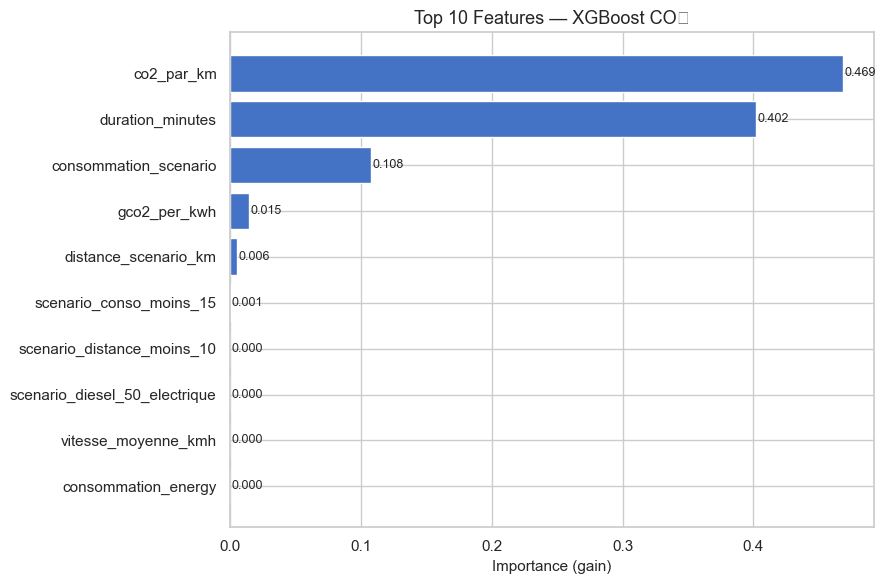

Figure sauvegardée : figures/REG_07_feature_importance.png


In [25]:
# Récupération des noms de features après preprocessing
feature_names_num = features_numeriques
feature_names_cat = list(
    best_model.named_steps['preparation']
    .named_transformers_['cat']
    .get_feature_names_out(features_categorielles)
)
all_feature_names = feature_names_num + feature_names_cat

# Importances XGBoost (gain)
importances = best_model.named_steps['modele'].feature_importances_
importance_df = pd.DataFrame({
    'Feature':    all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importance_df['Feature'], importance_df['Importance'],
        color='#4472C4', edgecolor='white')
ax.set_xlabel('Importance (gain)', fontsize=11)
ax.set_title('Top 10 Features — XGBoost CO₂', fontsize=13)

for i, (v, name) in enumerate(zip(importance_df['Importance'], importance_df['Feature'])):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('figures/REG/REG_07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : figures/REG_07_feature_importance.png')

## Section 15 — Sauvegarde du modèle

Sérialisation du pipeline complet (preprocesseur + modèle XGBoost optimisé) dans `models/`.  
Un seul fichier suffit — le `Pipeline` embarque à la fois le `ColumnTransformer` et le modèle.

In [26]:
joblib.dump(best_model, 'models/regression_co2.joblib')
print('Modèle sauvegardé : models/regression_co2.joblib')

size_kb = os.path.getsize('models/regression_co2.joblib') / 1024
print(f'Taille du fichier : {size_kb:.0f} KB')

Modèle sauvegardé : models/regression_co2.joblib
Taille du fichier : 1532 KB


## Section 16 — Script de prédiction standalone (`predict_co2.py`)

Génération de `predict_co2.py` via `%%writefile`.  
Le script charge le pipeline depuis `models/`, calcule les features dérivées et retourne le CO₂ estimé.  
Usage direct : `python predict_co2.py` — aucune dépendance au notebook.

In [27]:
%%writefile predict_co2.py
"""
predict_co2.py - Pipeline de prediction minimal pour l'estimation CO2 futur
Usage : python predict_co2.py
"""
import joblib
import pandas as pd
import numpy as np


def predict_co2(distance_km, duration_minutes, n_stops,
                consommation_energy, gco2_per_kwh, consommation_totale,
                type_train, scenario):
    """
    Predit les emissions CO2 futures d'une liaison ferroviaire selon un scenario.
    Scenarios disponibles : 'reference', 'diesel_50_electrique',
                            'conso_moins_15', 'distance_moins_10'
    Retourne la valeur estimee en kgCO2.
    """
    model = joblib.load('models/regression_co2.joblib')

    # Features derivees
    vitesse_moyenne_kmh = distance_km / (duration_minutes / 60) if duration_minutes > 0 else 0
    co2_par_km_base = (consommation_energy * gco2_per_kwh) / distance_km if distance_km > 0 else 0
    is_diesel   = 1 if type_train == 'diesel' else 0
    is_electric = 1 if type_train == 'electric' else 0

    # Adaptation selon le scenario
    distance_scenario_km  = distance_km
    consommation_scenario = consommation_totale

    if scenario == 'diesel_50_electrique' and type_train == 'diesel':
        consommation_scenario *= 0.50
    elif scenario == 'conso_moins_15':
        consommation_scenario *= 0.85
    elif scenario == 'distance_moins_10':
        distance_scenario_km  *= 0.90
        consommation_scenario *= 0.90

    X = pd.DataFrame([{
        'distance_scenario_km':  distance_scenario_km,
        'duration_minutes':      duration_minutes,
        'n_stops':               n_stops,
        'consommation_energy':   consommation_energy,
        'gco2_per_kwh':          gco2_per_kwh,
        'consommation_scenario': consommation_scenario,
        'vitesse_moyenne_kmh':   vitesse_moyenne_kmh,
        'co2_par_km':            co2_par_km_base,
        'is_diesel':             is_diesel,
        'is_electric':           is_electric,
        'type_train':            type_train,
        'scenario':              scenario
    }])

    co2_predit = model.predict(X)[0]
    print(f"Scenario     : {scenario}")
    print(f"CO2 estime   : {co2_predit:.4f} kgCO2")
    return co2_predit


if __name__ == '__main__':
    # Exemple : Paris -> Lyon, train diesel, scenario diesel_50_electrique
    predict_co2(
        distance_km=400,
        duration_minutes=120,
        n_stops=2,
        consommation_energy=10.0,
        gco2_per_kwh=21.7,
        consommation_totale=4000.0,
        type_train='diesel',
        scenario='diesel_50_electrique'
    )

Overwriting predict_co2.py


In [28]:
# Test rapide du script
print('Test du script predict_co2.py :')
%run predict_co2.py

Test du script predict_co2.py :
Scenario     : diesel_50_electrique
CO2 estime   : 64.7376 kgCO2


---

## Limites et perspectives

### Limites du modèle

- **Variable cible construite par simulation** : `kgCO2_futur` est calculée par des règles simples (pourcentages fixes), pas mesurée sur le terrain. Le modèle apprend à reproduire ces règles — pas un phénomène observé réellement.
- **Scénarios simplifiés** : pas de données tarifaires, pas de capacité réseau, pas de comportement voyageur — des hypothèses fortes sont faites sur l'élasticité des émissions.
- **4 pays uniquement** : le modèle est entraîné sur FR, ES, IT, DE. Sa généralisation à d'autres réseaux européens n'est pas testée.
- **Absence de dimension temporelle** : pas de saisonnalité, pas de jour de semaine — or les fréquences de service et les patterns de consommation varient.
- **Circularité partielle** : `consommation_scenario` et `co2_par_km` sont construites depuis les mêmes données que la cible — les performances élevées s'expliquent en partie par là.

### Pistes d'amélioration

- collecter des données réelles de suivi des émissions (rapports annuels des opérateurs, Eurostat)
- enrichir les scénarios avec des données tarifaires et de fréquence de service
- intégrer une dimension temporelle (série chronologique par corridor)
- étendre à d'autres pays européens pour améliorer la généralisation
- mettre en place un monitoring de drift (Evidently) pour détecter les dérives en production